## **Quickstart Guide**

This notebook use Gausian Process and twinlab to analyse, predict and improve the performance of a runner:

1. Upload a dataset to twinLab.
2. Use `Emulator.train` to train a surrogate model.
3. Use the model to make a prediction with `Emulator.predict`.
4. Visualise the results and their uncertainty.

### Data Cleaning



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
# Magic library
import twinlab as tl


          ====== TwinLab Client Initialisation ======
          Version     : 2.4.0
          Server      : http://127.0.0.1:3000
          Environment : /Users/sergiochavez/twinlab-demos/.env



In [2]:
df=pd.read_csv('activity_log.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Activity Type      689 non-null    object 
 1   Date               689 non-null    object 
 2   Title              689 non-null    object 
 3   Distance           689 non-null    float64
 4   Calories           689 non-null    object 
 5   Time               689 non-null    object 
 6   Avg HR             689 non-null    object 
 7   Max HR             689 non-null    object 
 8   Avg Run Cadence    689 non-null    object 
 9   Max Run Cadence    689 non-null    object 
 10  Avg Pace           689 non-null    object 
 11  Best Pace          689 non-null    object 
 12  Elev Gain          689 non-null    object 
 13  Elev Loss          689 non-null    object 
 14  Avg Stride Length  689 non-null    float64
 15  Best Lap Time      689 non-null    object 
 16  Number of Laps     689 non

In [3]:
### I. Data cleaning
# A. Date
df['datetime_column'] = pd.to_datetime(df['Date'], format='%m/%d/%y %H:%M').dt.date.astype('datetime64')
# B. Time
def time_to_minutes(time_str):
    #Clean values that have . instead of :
    time_str = time_str.replace('.', ':')
    # Split the time string into hours, minutes, and seconds
    hours, minutes, seconds = map(int, time_str.split(':'))
    
    # Convert hours and seconds into minutes, then add them together
    total_minutes = hours * 60 + minutes + seconds / 60.0
    return total_minutes
# Apply the conversion function to the entire column
df['Time_minutes'] = df['Time'].apply(time_to_minutes)
# C. Average Heart Rate
df['Average_HR']=df['Avg HR'].replace('--', np.nan).astype(float)
# D. Average run cadence
df['Average_Cadence']=df['Avg Run Cadence'].replace('--', np.nan).astype(float)
# E. Average pace (In minutes per mile)
def pace_to_minutes(pace_str):
    #Clean values that have . instead of :
    pace_str = pace_str.replace('.', ':')
    # nan values
    if pace_str == '--':
        return np.nan
    # Split the pace string into minutes and seconds
    minutes, seconds = map(int, pace_str.split(':'))
    
    # Convert minutes and seconds into minutes
    total_minutes = minutes + seconds / 60.0
    return total_minutes
# Apply the conversion function to the entire column
df['Average_Pace'] = df['Avg Pace'].apply(pace_to_minutes)
# E. Elevation Gain
df['Elevation_Gain']=df['Elev Gain'].replace('--', np.nan).str.replace(",","").astype(float)
# F. Elevation Loss
df['Elevation_Loss']=df['Elev Loss'].replace('--', np.nan).str.replace(",","").astype(float)

### II. Data builiding

data=df[['Activity Type','Title','datetime_column','Distance','Time_minutes','Average_HR','Average_Cadence','Average_Pace','Elevation_Gain','Elevation_Loss']].sort_values(by='datetime_column').reset_index(drop=True)
data

,Activity Type,Title,datetime_column,Distance,Time_minutes,Average_HR,Average_Cadence,Average_Pace,Elevation_Gain,Elevation_Loss
0,Running,Baltimore Running,2018-05-29,4.02,29.533333,150.0,170.0,7.350000,197.0,204.0
1,Running,Baltimore Running,2018-05-30,4.15,30.466667,147.0,168.0,7.333333,180.0,177.0
2,Running,Baltimore Running,2018-05-31,5.98,45.283333,149.0,168.0,7.566667,322.0,322.0
3,Running,Baltimore Running,2018-06-01,6.03,42.400000,159.0,170.0,7.033333,382.0,387.0
4,Running,Baltimore Running,2018-06-03,7.96,55.550000,170.0,170.0,6.983333,669.0,679.0
...,...,...,...,...,...,...,...,...,...,...
684,Running,Cherry Hill Running,2020-07-11,5.19,41.583333,129.0,170.0,8.016667,76.0,80.0
685,Running,Cherry Hill Running,2020-07-12,7.01,52.916667,142.0,172.0,7.550000,215.0,219.0
686,Running,Cherry Hill Running,2020-07-13,5.01,40.483333,128.0,170.0,8.083333,124.0,124.0
687,Running,Cherry Hill Running,2020-07-14,6.50,47.066667,144.0,172.0,7.233333,183.0,187.0


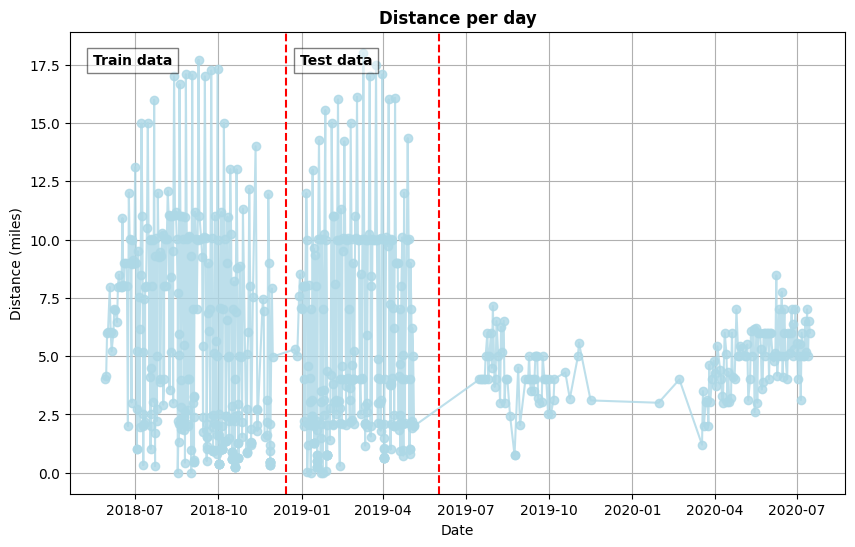

In [4]:
### III. Data analysis
# Distance
plt.figure(figsize=(10,6))
plt.plot(data['datetime_column'], data['Distance'], marker='o', color='lightblue', alpha=0.8)
plt.axvline(x=datetime(2018,12,15), color='red', linestyle='--')
plt.text(datetime(2018,5,15), 17.5, 'Train data', color='black', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
plt.axvline(x=datetime(2019,6,1), color='red', linestyle='--')
plt.text(datetime(2018,12,30), 17.5, 'Test data', color='black', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
plt.title('Distance per day', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Distance (miles)')
plt.grid(True)
plt.show()


In [5]:
# Create a subset that only consider info of 2018 (First block)
first_block=data[data['datetime_column']<datetime(2019,1,1)]
# Only consider distances greater than 13.1 miles
firstblock_halfmarathon=first_block[first_block['Distance']>13.1]
firstblock_halfmarathon=firstblock_halfmarathon.dropna()
firstblock_halfmarathon

,Activity Type,Title,datetime_column,Distance,Time_minutes,Average_HR,Average_Cadence,Average_Pace,Elevation_Gain,Elevation_Loss
30,Running,Baltimore Running,2018-07-01,13.11,94.450000,146.0,172.0,7.200000,804.0,766.0
41,Running,Baltimore County Running,2018-07-08,14.98,100.933333,151.0,174.0,6.733333,1088.0,1077.0
64,Running,Ocean City Running,2018-07-22,16.00,115.616667,143.0,176.0,7.233333,145.0,145.0
95,Running,Cherry Hill Running,2018-08-13,17.00,120.000000,154.0,174.0,7.066667,470.0,476.0
106,Running,Baltimore Running,2018-08-19,16.66,118.983333,145.0,176.0,7.133333,1000.0,991.0
121,Running,Howard County Running,2018-08-26,17.09,114.900000,149.0,176.0,6.716667,685.0,690.0
133,Running,Baltimore Running,2018-09-02,17.06,116.133333,157.0,176.0,6.800000,1036.0,1030.0
146,Running,Baltimore Running,2018-09-09,17.71,116.116667,150.0,178.0,6.550000,1067.0,1073.0
154,Running,Philadelphia Running,2018-09-16,17.00,113.616667,151.0,176.0,6.683333,1198.0,1198.0
168,Running,Baltimore Running,2018-09-23,17.25,113.000000,131.0,178.0,6.550000,1041.0,1055.0


In [6]:
# Create a subset that only consider info from Jan 2019 to May 2019 (Second block)
second_block=data[(data['datetime_column']>=datetime(2019,1,1)) & (data['datetime_column']<datetime(2019,6,1))]
# Now only consider distances greater than 13.1 miles
secondblock_halfmarathon=second_block[second_block['Distance']>13.1]
second_block_halfmarathon=secondblock_halfmarathon.dropna()
second_block_halfmarathon


,Activity Type,Title,datetime_column,Distance,Time_minutes,Average_HR,Average_Cadence,Average_Pace,Elevation_Gain,Elevation_Loss
351,Running,Baltimore Running,2019-01-20,14.25,94.833333,153.0,180.0,6.650000,793.0,793.0
365,Running,Baltimore Running,2019-01-27,15.55,101.950000,157.0,178.0,6.550000,827.0,822.0
379,Running,Philadelphia Running,2019-02-03,15.01,105.566667,146.0,178.0,7.033333,643.0,645.0
391,Running,Baltimore County Running,2019-02-10,16.01,103.500000,140.0,178.0,6.466667,1061.0,1062.0
404,Running,Running,2019-02-17,14.21,94.000000,146.0,178.0,6.616667,819.0,814.0
416,Running,Baltimore Running,2019-02-24,15.00,112.133333,129.0,176.0,7.466667,818.0,822.0
428,Running,Baltimore - Running,2019-03-03,16.12,108.950000,121.0,180.0,6.750000,1026.0,1021.0
437,Running,Philadelphia - Running,2019-03-10,18.01,118.533333,149.0,176.0,6.583333,506.0,505.0
451,Running,Santurce - Running,2019-03-17,17.00,116.700000,146.0,178.0,6.866667,430.0,429.0
459,Running,Baltimore Running,2019-03-24,17.50,119.316667,142.0,180.0,6.816667,971.0,978.0


In [ ]:
emulator.plot(x_axis='Distnace',y_axis='Time_minutes')

In [7]:
# Recreate the dataframe but without the three first columns
datatest_2ndoblock = second_block_halfmarathon[['Distance','Time_minutes','Average_HR','Average_Cadence','Average_Pace','Elevation_Gain','Elevation_Loss']]

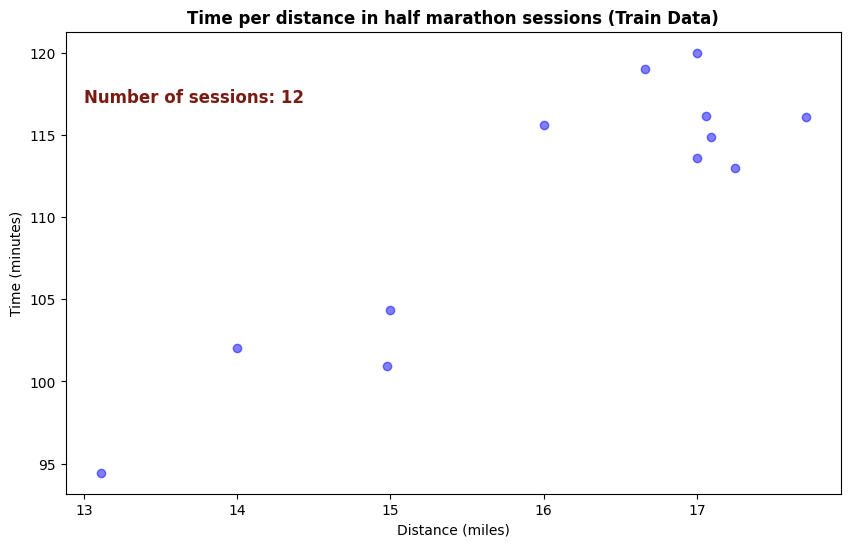

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(firstblock_halfmarathon['Distance'], firstblock_halfmarathon['Time_minutes'],marker='o',color='blue',alpha=0.5)
plt.title('Time per distance in half marathon sessions (Train Data)', fontweight="bold")
plt.xlabel('Distance (miles)')
plt.ylabel('Time (minutes)' )
plt.text(13, 117, 'Number of sessions: '+str(firstblock_halfmarathon.shape[0]), fontsize=12, color='#781B12',fontweight="bold")
plt.show()


In [9]:
# Recreate the dataframe but without the three first columns
data_train_firstblock=firstblock_halfmarathon[['Distance','Time_minutes','Average_HR','Average_Cadence','Average_Pace','Elevation_Gain','Elevation_Loss']]
outputs = ['Time_minutes']
inputs = ['Distance','Average_HR','Average_Cadence','Average_Pace','Elevation_Gain','Elevation_Loss']


# Using twinlab to build a GP

In [10]:
#Whole mode
#Create dataset
dataset=tl.Dataset(id='runnig_df_x')
dataset.upload(data_train_firstblock, verbose=True)
#Create a model
emulator = tl.Emulator(id='running_emulator')
params = tl.TrainParams(train_test_ratio=0.8, input_explained_variance=0.99, seed=123)
emulator.train(dataset, inputs=inputs, outputs=outputs, params=params, verbose=True)

Dataframe is uploading.
Processing dataset
Dataset runnig_df_x was processed.
Model running_emulator has begun training.
Emulator running_emulator with process ID 060c7983-754c-4908-a6b4-f60f4486ba2b is training.
Training status: processing_Modal
Training status: done_Modal
Training of emulator running_emulator with process ID 060c7983-754c-4908-a6b4-f60f4486ba2b is complete!


<module 'matplotlib.pyplot' from '/Users/sergiochavez/Library/Caches/pypoetry/virtualenvs/twinlab-demos-Z5dyJhMx-py3.11/lib/python3.11/site-packages/matplotlib/pyplot.py'>

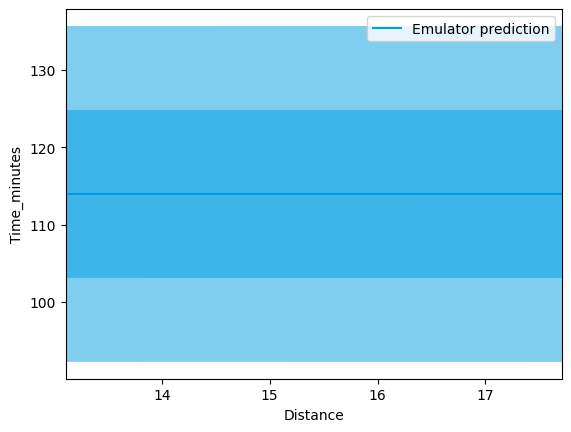

In [14]:
# Bug - specifying one variable
x_fixed = {
    "Elevation_Gain": 0,
    "Elevation_Loss": 0,
    "Average_HR": 150,
    "Average_Cadence": 180,
    "Average_Pace": 7,
}
emulator.plot(x_axis='Distance', y_axis='Time_minutes', x_fixed=x_fixed, label='Emulator prediction')

In [ ]:
emulator.plot(x_axis=inputs,y_axis='Time_minutes',label='Emulator prediction')

In [16]:
# Emulator that only use distance as input
emulator_distance = tl.Emulator(id='running_emulator_distance')
params2 = tl.TrainParams(train_test_ratio=0.8, seed=123)
emulator_distance.train(dataset, inputs=['Distance'], outputs=outputs, params=params2, verbose=True)

Model running_emulator_distance has begun training.
Emulator running_emulator_distance with process ID 1c49cf02-801a-42f5-9f57-0d7d78b78519 is training.
Training status: loading_AWS
Training status: loading_AWS
Training status: loading_AWS
Training status: processing_Modal
Training status: done_Modal
Training of emulator running_emulator_distance with process ID 1c49cf02-801a-42f5-9f57-0d7d78b78519 is complete!


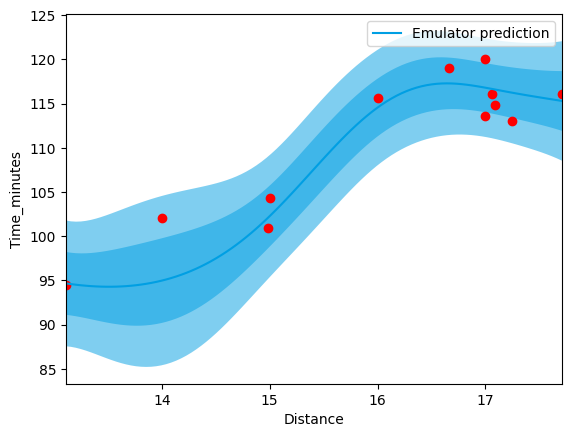

In [17]:
emulator_distance.plot(x_axis='Distance',y_axis='Time_minutes', label='Emulator prediction')
plt.scatter(data_train_firstblock['Distance'], data_train_firstblock['Time_minutes'], color='red', label='Real data')
plt.show()

In [ ]:
# Now using the whole data model
predictions=emulator.predict(datatest_2ndoblock)
type(predictions)

In [15]:
predictions

NameError: name 'predictions' is not defined

In [ ]:
# Is a tuple with 2 dataframe elements
mean_prediction=predictions[0]
std_prediction=predictions[1]
real_predictions=pd.concat([mean_prediction,std_prediction], axis=1)
# Thi should be the standard result
real_predictions.columns=['Prediction_mean','Prediction_std']
real_predictions

In [ ]:
type(datatest_2ndoblock['Time_minutes'])

In [ ]:
results=pd.concat([datatest_2ndoblock[['Time_minutes']].reset_index(drop=True), real_predictions], axis=1)

In [ ]:
#Ploting the results

# Calculate differences
differences = results['Time_minutes'] - results['Prediction_mean']

# Plot scatter plot with error bars
plt.figure(figsize=(8, 6))
plt.errorbar(results['Time_minutes'], differences, yerr=results['Prediction_std'], fmt='o', color='blue', label='Difference with Std Dev')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Time in minutes (Real values)')
plt.ylabel('Difference (Predicted - True)')
plt.title('Difference between predicted and true values',fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()